# 15 - LSTM incremental history (the contribution)
Does readmission prediction improve as we feed more of a patient's visit history?
One padded sequence per patient; LSTM predicts at every visit; read AUROC at visit 1,2,3...
GPU recommended - run this in Colab (T4). Reads `patient_sequences.csv`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data prep
Build [patients x visits x features], a per-visit target (readmit within 30d), and a mask.
Sort/index on raw visit_num BEFORE scaling (scaling visit_num would corrupt the timestep).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings; warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

DATA_DIR = "/Users/robert/Desktop/hospital-re-admission/data/processed"
RESULTS_DIR = "/Users/robert/Desktop/hospital-re-admission/notebooks/15_lstm_incremental"

os.makedirs(RESULTS_DIR, exist_ok=True)

MAXLEN = 5
SEED = 42
np.random.seed(SEED)

In [3]:
seq = pd.read_csv(f"/content/patient_sequences.csv")
cat_cols = ["gender", "race", "marital_status", "language", "insurance",
            "admission_type", "admission_location", "discharge_location"]
non_features = ["subject_id", "tgt_bucket", "tgt_days", "split"]
features = [c for c in seq.columns if c not in non_features]

# Target: readmitted within 30 days after this visit.
seq["y"] = (seq["tgt_days"] <= 30).fillna(False).astype(int)
for c in cat_cols:
    seq[c] = LabelEncoder().fit_transform(seq[c].astype(str))

# Order and cap on the RAW visit_num, then build the index, then scale.
seq = seq.sort_values(["subject_id", "visit_num"]).reset_index(drop=True)
seq = seq[seq["visit_num"] <= MAXLEN].reset_index(drop=True)

pids = seq["subject_id"].drop_duplicates().to_numpy()
N, nfeat = len(pids), len(features)
row_of = pd.Series(np.arange(N, dtype=np.int64), index=pids)
ri = row_of.loc[seq["subject_id"]].to_numpy(dtype=np.int64)
ti = (seq["visit_num"].to_numpy() - 1).astype(np.int64)

is_train_row = (seq["split"] == "train").to_numpy()
seq[features] = StandardScaler().fit(seq.loc[is_train_row, features]).transform(seq[features])

X = np.zeros((N, MAXLEN, nfeat), dtype="float32")
Y = np.zeros((N, MAXLEN), dtype="float32")
mask = np.zeros((N, MAXLEN), dtype="float32")
X[ri, ti] = seq[features].to_numpy()
Y[ri, ti] = seq["y"].to_numpy()
mask[ri, ti] = 1.0

split = seq.groupby("subject_id")["split"].first().loc[pids].to_numpy()
is_tr = split == "train"
print("X", X.shape, "| patients per visit:", mask.sum(0).astype(int).tolist())
print("train/test patients:", int(is_tr.sum()), int((~is_tr).sum()))

X (180352, 5, 48) | patients per visit: [180352, 77529, 41674, 25569, 17228]
train/test patients: 144281 36071


## Build and train the LSTM
Masking ignores padded visits; the LSTM outputs a prediction at every real visit.
Padded steps get zero loss weight; positives get up-weighted for the imbalance.

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, TimeDistributed, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(SEED)
Xtr, Ytr, Mtr = X[is_tr], Y[is_tr], mask[is_tr]
Xte, Yte, Mte = X[~is_tr], Y[~is_tr], mask[~is_tr]

# Sample weights: 0 on padding, up-weight positives to handle imbalance.
pos_rate = Ytr[Mtr == 1].mean()
pos_w = (1 - pos_rate) / pos_rate
sw = Mtr * np.where(Ytr == 1, pos_w, 1.0)

model = Sequential([
    Masking(mask_value=0.0, input_shape=(MAXLEN, X.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    TimeDistributed(Dense(1, activation="sigmoid")),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy")

# More epochs + early stopping so it actually converges (8 was too few).
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
model.fit(Xtr, Ytr[..., None], sample_weight=sw, epochs=40, batch_size=256,
          validation_split=0.1, callbacks=[es], verbose=1)

Epoch 1/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 1.1163 - val_loss: 1.1099
Epoch 2/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1.1022 - val_loss: 1.1061
Epoch 3/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.0962 - val_loss: 1.1038
Epoch 4/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.0917 - val_loss: 1.1037
Epoch 5/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 1.0875 - val_loss: 1.1046
Epoch 6/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.0822 - val_loss: 1.1049
Epoch 7/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 1.0769 - val_loss: 1.1076
Epoch 8/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.0713 - val_loss: 1.1105
Epoch 9/40
508/508 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 1.0649 - val_loss: 1.1175


## Incremental evaluation
For each visit position, score only patients who actually reached that visit.
If AUROC rises with visit number, more history helps - that is the finding.

In [5]:
proba = model.predict(Xte, batch_size=512)[..., 0]

rows = []
for t in range(MAXLEN):
    who = Mte[:, t] == 1
    if who.sum() < 50:
        continue
    yt = Yte[who, t]; ps = proba[who, t]
    pred = (ps >= 0.5).astype(int)
    rows.append({"visit": t + 1, "patients": int(who.sum()),
                 "accuracy": round(accuracy_score(yt, pred), 3),
                 "precision": round(precision_score(yt, pred, zero_division=0), 3),
                 "recall": round(recall_score(yt, pred, zero_division=0), 3),
                 "f1": round(f1_score(yt, pred, zero_division=0), 3),
                 "auroc": round(roc_auc_score(yt, ps), 3)})
incr = pd.DataFrame(rows)
print(incr.to_string(index=False))
incr.to_csv(f"{RESULTS_DIR}/15_incremental_scores.csv", index=False)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
 visit  patients  accuracy  precision  recall    f1  auroc
     1     36071     0.727      0.201   0.429 0.274  0.649
     2     15569     0.566      0.214   0.682 0.326  0.662
     3      8356     0.478      0.237   0.817 0.367  0.673
     4      5134     0.442      0.253   0.864 0.391  0.675
     5      3481     0.407      0.262   0.875 0.403  0.651


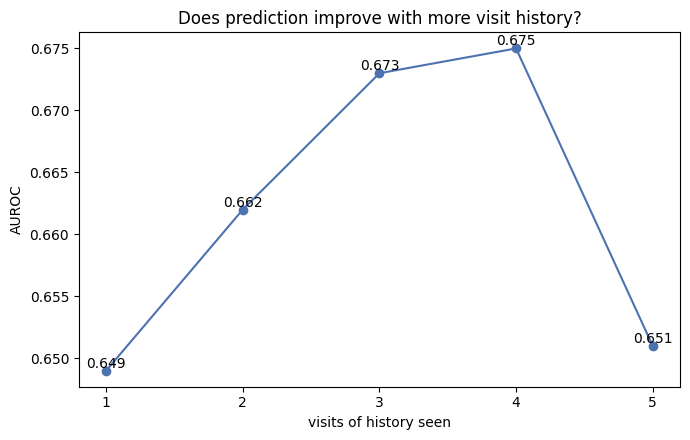

In [6]:
# Headline figure: AUROC vs how many visits of history the model has seen.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(incr["visit"], incr["auroc"], marker="o", color="#4c72b0")
for _, r in incr.iterrows():
    ax.text(r["visit"], r["auroc"], f"{r['auroc']:.3f}", ha="center", va="bottom")
ax.set_xlabel("visits of history seen"); ax.set_ylabel("AUROC")
ax.set_title("Does prediction improve with more visit history?")
ax.set_xticks(incr["visit"])
plt.tight_layout(); plt.savefig(f"{RESULTS_DIR}/15_auroc_vs_history.png", dpi=150); plt.show()

In [7]:
rate_rows = []
for t in range(MAXLEN):
    who = Mte[:, t] == 1
    if who.sum() < 50:
        continue
    yt = Yte[who, t]
    rate_rows.append({
        "visit": t + 1,
        "patients": int(who.sum()),
        "readmit_rate_30d": round(yt.mean(), 3)
    })

rate_df = pd.DataFrame(rate_rows)
print(rate_df.to_string(index=False))
rate_df.to_csv(f"{RESULTS_DIR}/15_readmit_rate_by_visit.csv", index=False)

 visit  patients  readmit_rate_30d
     1     36071             0.120
     2     15569             0.154
     3      8356             0.185
     4      5134             0.208
     5      3481             0.229
